# Import thu vien

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras

# Import du lieu

In [3]:
(X_train, y_train),(X_test, y_test)=keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [5]:
X_train.shape,y_train.shape,X_test.shape,y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

<function matplotlib.pyplot.show(close=None, block=None)>

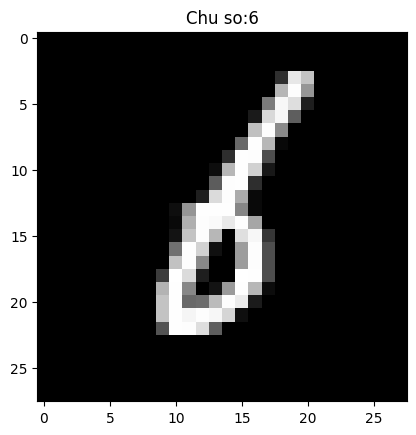

In [6]:
#xem thu hin anh tao du lieu
import matplotlib.pyplot as plt
from PIL import Image

ind_data=256
img=Image.fromarray(X_train[ind_data])
plt.imshow(img, cmap="gray")
plt.title("Chu so:"+str(y_train[ind_data]))
plt.show

# Chuan hóa dữ liệu

**Tham số cần lưu ý:**
- `n`: số hình (60000)
- `w`: chiều rộng (28)
- `h`: chiều cao (28)
- `d`: direction (vì hình trắng đen nên chọn **d = 1**, hình có màu RGB thì **d = 3**)
- `class`: số lớp (kết quả bao gồm các lớp với % khác nhau: [0: 1, 1: 00.0, ...])


In [8]:
# scale ma mau 0-> 255 =>[0,....,1]
X_train=X_train.astype("float64")/255
X_test=X_test.astype('float64')/255

X_train.shape, X_test.shape

((60000, 28, 28), (10000, 28, 28))

In [13]:
# them chieu d
X_train=np.expand_dims(X_train,axis=-1)
X_test=np.expand_dims(X_test,axis=-1)
X_train.shape,X_test.shape

((60000, 28, 28, 1, 1), (10000, 28, 28, 1, 1))

In [16]:
#Them lop
my_classes=10
y_train=keras.utils.to_categorical(y_train,my_classes)
y_test=keras.utils.to_categorical(y_test,my_classes)
y_train.shape,y_test.shape

((60000, 10), (10000, 10))

# Huan luyen mo hinh

In [17]:
# khai bao mo hinh
input_shape = (28, 28, 1)
model = keras.Sequential([
    keras.layers.Conv2D(32, kernel_size=(3, 3), input_shape=input_shape),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    
    keras.layers.Conv2D(64, kernel_size=(3, 3)), # tang do phuc tap cho mo hinh
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    
    keras.layers.Flatten(), # chuyen 2D -> 1D
    keras.layers.Dense(my_classes, activation="softmax"), # lop output (phan lop)
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

c:\Users\lazyg\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
#hoc
batch_size = 128 # số lượng ảnh mẫu được xử lý mỗi lần mô hình cập nhật trọng số
epochs =10   # số lần mô hình sẽ được huấn luyện trên toàn bộ tập dữ liệu
validation_split = 0.2 # phần trăm dữ liệu huấn luyện được sử dụng để đánh giá mô hình trong quá trình huấn luyện
model.fit(
    X_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=validation_split,
)

Epoch 1/10
289/375 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3795 - loss: 1.8170

# Danh gia mo hinh

In [18]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Độ chính xác trên tập kiểm tra: {accuracy:.4f}") # học được bao nhiều phần trăm từ dữ liệu
print(f"Độ mất mát trên tập kiểm tra: {loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1010 - loss: 2.3026
Độ chính xác trên tập kiểm tra: 0.1010
Độ mất mát trên tập kiểm tra: 2.3026


# Du doan mo hinh


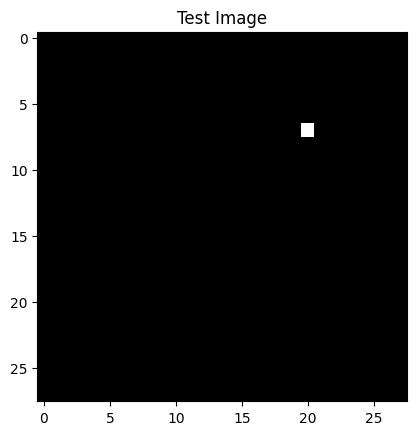

In [21]:
test_img = X_test[10]
# VE HINH ANH TEST
img = Image.fromarray((test_img.squeeze() * 255).astype('uint8'))
plt.imshow(img, cmap='gray')
plt.title("Test Image")
plt.show()

In [22]:
test_img = np.expand_dims(test_img, 0)
preds = model.predict(test_img)
print(preds)
test_pred = np.argmax(preds)
print(f"Predicted class = {test_pred}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
[[9.9996483e-01 4.8101557e-11 1.2994441e-05 7.9366069e-09 1.0992486e-11
  7.6607503e-06 6.7915607e-06 9.8789388e-10 7.1635900e-06 6.1221533e-07]]
Predicted class = 0
